In [1]:
%matplotlib inline

# Product Fractionation

- Key information for evaluating the separation performance of a chromatographic process: Amounts of the target components in the collected product fractions.
- Evaluation of chromatograms $c_{i,k}\left(t\right)$ at the outlet(s) of the process must be evaluated.

$$
m_{i} = \sum_{k=1}^{n_{\text{chrom}}} \sum_{j=1}^{n_{\text{frac}, k}^{i}}\int_{t_{\text{start}, j}}^{t_{\text{end}, j}} Q_k(t) \cdot c_{i,k}(t) dt, \\
$$

where $n_{\text{frac}, k}^{i}$ is the number of fractions considered for component $i$ in chromatogram $k$, and $n_{\text{chrom}}$ is the total number of chromatograms evaluated.

## Key Performance Indicators (KPI)

### Productivity
$$
PR_{i} = \frac{m_i}{V_{\text{solid}} \cdot \Delta t_{\text{cycle}}},\\
$$
with $V_{\text{solid}}$: volume of stationary phase.

### Recovery Yield
$$
Y_{i} = \frac{m_i}{m_{\text{feed}, i}},\\
$$
with $m_{\text{feed}}$: injected amount of mixture.

### Eluent Consumption
$$
EC_{i} = \frac{V_{\text{solvent}}}{m_i}.\\
$$
with $V_{\text{solvent}}$: solvent used during a cycle.

### Purity

$$
PU_{i} = \frac{m_{i}^{i}}{\sum_{l=1}^{n_{\text{comp}}} m_{l}^{i}},\\
$$
where $n_{\text{comp}}$ is the number of mixture components and $m_{l}^{i}$ is the mass of component $l$ in target fraction $i$.

## Fractionator

In **CADET-Process**, the `fractionation` module provides methods to calculate these performance indicators.

The `Fractionator` allows slicing the solution and pool fractions for the individual components.
It enables evaluating multiple chromatograms at once and multiple fractions per component per chromatogram.

The most basic strategy is to manually set all fractionation times manually.
To demonstrate the strategy, a process from the [examples collection](https://cadet-process.readthedocs.io/en/latest/examples/batch_elution/process.html) is used.

In [2]:
from examples.batch_elution.process import process

To enable the calculation of the process parameters, it is necessary to specify which of the inlets should be considered for the feed and eluent consumption.
Moreover, the outlet(s) which are used for evaluation need to be defined.

```
process.flow_sheet.add_feed_inlet('feed')
process.flow_sheet.add_eluent_inlet('eluent')
process.flow_sheet.add_chromatogram_outlet('outlet')
```

In [3]:
from CADETProcess.simulator import Cadet
process_simulator = Cadet()
simulation_results = process_simulator.simulate(process)

For reference, this is the chromatogram at the outlet that needs to be fractionated:

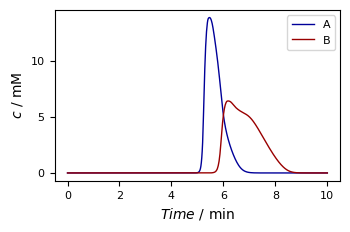

In [4]:
_ = simulation_results.solution.outlet.outlet.plot()

After import, the `Fractionator` is instantiated with the simulation results.

In [5]:
from CADETProcess.fractionation import Fractionator
fractionator = Fractionator(simulation_results)

[WARNING 03-30 22:29:04] ax.storage.sqa_store.with_db_settings_base: Ax currently requires a sqlalchemy version below 2.0. This will be addressed in a future release. Disabling SQL storage in Ax for now, if you would like to use SQL storage please install Ax with mysql extras via `pip install ax-platform[mysql]`.


To add a fractionation event, the following arguments need to be provided:
- `event_name`: Name of the event.
- `target`: Pool to which fraction is added. `-1` indicates waste.
- `time`: Time of the event
- `chromatogram`: Name of the chromatogram. Optional if only one outlet is set as `chromatogram_sink`.

Here, component $A$ seems to have sufficient purity between $\text{5:00}~min$ and $\text{5:45}~min$ and component $B$ between $\text{6:30}~min$ and $\text{9:00}~min$.

In [6]:
fractionator.add_fractionation_event('start_A', 0, 5*60, 'outlet')
fractionator.add_fractionation_event('end_A', -1, 5.75*60)
fractionator.add_fractionation_event('start_B', 1, 6.5*60)
fractionator.add_fractionation_event('end_B', -1, 9*60)

The `performance` object of the `Fractionator` contains the parameters:

In [7]:
print(fractionator.performance)

Performance(mass=array([0.00039127, 0.00038088]), concentration=array([8.69481923, 2.5392047 ]), purity=array([0.99721982, 0.97224997]), recovery=array([0.65211144, 0.63480118]), productivity=array([0.00800824, 0.00779566]), eluent_consumption=array([0.72456827, 0.70533464]) mass_balance_difference=array([-1.66089873e-10,  1.07870543e-10]))


With these fractionation times, the both component fractions reach a purity of $99.7~\%$, and $97.2~\%$  respectively.
The recovery yields are $65.2~\%$ and $63.4~\%$.

The chromatogram can be plotted with the fraction times overlaid:

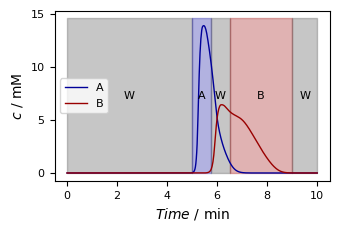

In [8]:
_ = fractionator.plot_fraction_signal()

## Optimization of Fractionation Times
- The `fractionation` module provides tools to automatically determines optimal cut times.
- By default, the mass of the components is maximized under purity constraints.
- Different purity requirements can be specified for each component

In [9]:
from CADETProcess.fractionation import FractionationOptimizer
fractionation_optimizer = FractionationOptimizer()
fractionation_optimizer.optimizer.rhobeg = 1e-3  # more on that later!

To automatically optimize the fractionation times, pass the simulation results to the `optimize_fractionation` function.

In [10]:
fractionator = fractionation_optimizer.optimize_fractionation(simulation_results, purity_required=[0.95, 0])

The results are stored in a `Performance` object.

In [11]:
print(fractionator.performance)

Performance(mass=array([0.00050024, 0.        ]), concentration=array([5.0787505, 0.       ]), purity=array([0.94883636, 0.        ]), recovery=array([0.83373868, 0.        ]), productivity=array([0.01023871, 0.        ]), eluent_consumption=array([0.92637632, 0.        ]) mass_balance_difference=array([-1.46458475e-10,  1.21673874e-10]))


The chromatogram can also be plotted with the fraction times overlaid:

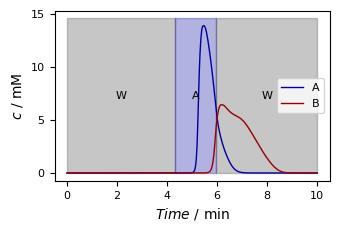

In [12]:
_ = fractionator.plot_fraction_signal()

For comparison, this is the results if only the second component is relevant:

Performance(mass=array([0.       , 0.0004368]), concentration=array([0.        , 1.89739537]), purity=array([0.        , 0.94759433]), recovery=array([0.        , 0.72800451]), productivity=array([0.        , 0.00894024]), eluent_consumption=array([0.       , 0.8088939]) mass_balance_difference=array([1.08641069e-13, 7.39990610e-11]))


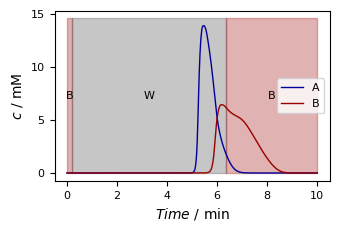

In [13]:
fractionator = fractionation_optimizer.optimize_fractionation(simulation_results, purity_required=[0, 0.95])

print(fractionator.performance)
_ = fractionator.plot_fraction_signal()

But of course, also both components can be valuable.
Here, the required purity is also reduced to demonstrate that overlapping fractions are automatically avoided by internally introducing linear constraints.

Performance(mass=array([0.00050889, 0.0005652 ]), concentration=array([5.25622079, 2.51345157]), purity=array([0.93599246, 0.86117734]), recovery=array([0.8481484 , 0.94199982]), productivity=array([0.01041566, 0.0115682 ]), eluent_consumption=array([0.94238711, 1.04666647]) mass_balance_difference=array([-1.68953286e-10,  1.10079079e-10]))


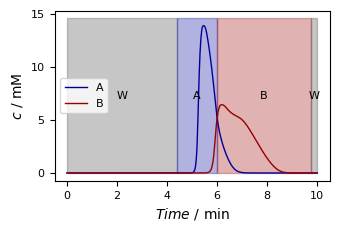

In [14]:
fractionator = fractionation_optimizer.optimize_fractionation(simulation_results, purity_required=[0.8, 0.8])

print(fractionator.performance)
_ = fractionator.plot_fraction_signal()

## Alternative Objectives

- define function that that takes a `Performance` as an input.
- Here, also consider concentration of the fraction.

```{note}
As previously mentioned, `COBYLA` only handles single objectives.
Hence, a `RankedPerformance` is used which transforms the `Performance` object by adding a weight $w_i$ to each component.
```

$$
p = \frac{\sum_i^{n_{comp}}w_i \cdot p_i}{\sum_i^{n_{comp}}(w_i)}
$$

It is also important to remember that by convention, objectives are minimized.
Since in this example, the product of mass and concentration should be maximized, the value of the objective function is multiplied by $-1$.

In [15]:
from CADETProcess.performance import RankedPerformance
ranking = [1, 1]

def alternative_objective(performance):
    performance = RankedPerformance(performance, ranking)
    return - performance.mass * performance.concentration

fractionator = fractionation_optimizer.optimize_fractionation(
    simulation_results, purity_required=[0.95, 0.95],
    obj_fun=alternative_objective,
)

Performance(mass=array([0.00046055, 0.0004137 ]), concentration=array([11.41010782,  3.96771329]), purity=array([0.9674507 , 0.94972469]), recovery=array([0.76758142, 0.68950038]), productivity=array([0.00942626, 0.00846739]), eluent_consumption=array([0.85286824, 0.76611153]) mass_balance_difference=array([2.08709421e-10, 1.07888184e-10]))


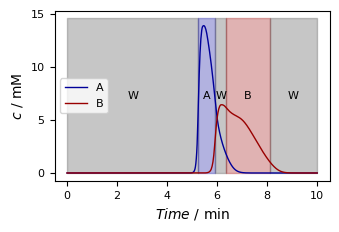

In [16]:
print(fractionator.performance)
_ = fractionator.plot_fraction_signal()

The resulting fractionation times show that in this case, it is advantageous to discard some slices of the peak in order not to dilute the overall product fraction.